# Text Classification: Multiclass Sentiment Analysis

This notebook implements three different approaches for text classification:
1. Word2Vec + Multinomial Logistic Regression
2. Word2Vec + MLP
3. Embedding from Scratch + MLP

Dataset: [Multiclass Sentiment Analysis](https://huggingface.co/datasets/Sp1786/multiclass-sentiment-analysis-dataset)

## 1. Setup and Data Loading

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from datasets import load_dataset
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from collections import Counter
import re
import random
import nltk
from nltk.tokenize import word_tokenize

# Set random seeds
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [25]:
# Load dataset
dataset = load_dataset("Sp1786/multiclass-sentiment-analysis-dataset")
print("Dataset structure:", dataset)

# Convert to pandas for easier manipulation
full_train_df = pd.DataFrame(dataset['train'])

print(f"\nTotal training samples: {len(full_train_df)}")
print(f"\nSample data:")
print(full_train_df.head())
print(f"\nLabel distribution:")
print(full_train_df['label'].value_counts())

# Split into train and validation (80/20)

train_df, val_df = train_test_split(full_train_df, test_size=0.2, random_state=42, stratify=full_train_df['label'])

print(f"Validation samples: {len(val_df)}")

train_df = train_df.reset_index(drop=True)

print(f"\nTraining samples: {len(train_df)}")

val_df = val_df.reset_index(drop=True)

Dataset structure: DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 31232
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 5205
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 5206
    })
})

Total training samples: 31232

Sample data:
      id                                               text  label sentiment
0   9536                    Cooking microwave pizzas, yummy      2  positive
1   6135  Any plans of allowing sub tasks to show up in ...      1   neutral
2  17697   I love the humor, I just reworded it. Like sa...      2  positive
3  14182                       naw idk what ur talkin about      1   neutral
4  17840          That sucks to hear. I hate days like that      0  negative

Label distribution:
label
1    11649
2    10478
0     9105
Name: count, dtype: int64
Validation samples: 6247

Training samples: 2

## 2. Data Preprocessing

In [26]:
# Download required NLTK data
nltk.download('punkt', quiet=True)

def preprocess_text(text):
    """Preprocess text: lowercase, remove special characters, tokenize"""
    # Handle None or empty text
    if text is None or not isinstance(text, str):
        return []
    
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove short tokens
    tokens = [t for t in tokens if len(t) > 2]
    return tokens

# Preprocess all texts
train_df['tokens'] = train_df['text'].apply(preprocess_text)
val_df['tokens'] = val_df['text'].apply(preprocess_text)

print("Sample tokenized text:")
print(f"Original: {train_df['text'].iloc[0]}")
print(f"Tokens: {train_df['tokens'].iloc[0]}")

Sample tokenized text:
Original: UI is nice, but task lists are useless to me unless they let you set a start date. I thought that since this was Microsoft's task list app, it would have similar features to the tasks in Outlook.
Tokens: ['nice', 'but', 'task', 'lists', 'are', 'useless', 'unless', 'they', 'let', 'you', 'set', 'start', 'date', 'thought', 'that', 'since', 'this', 'was', 'microsofts', 'task', 'list', 'app', 'would', 'have', 'similar', 'features', 'the', 'tasks', 'outlook']


## 3. Data Augmentation

In [27]:
def synonym_replacement(tokens, n=1):
    """Simple augmentation by random word deletion"""
    if len(tokens) <= 1:
        return tokens
    new_tokens = tokens.copy()
    for _ in range(n):
        if len(new_tokens) > 1:
            idx = random.randint(0, len(new_tokens) - 1)
            new_tokens.pop(idx)
    return new_tokens

def random_swap(tokens, n=1):
    """Randomly swap words"""
    new_tokens = tokens.copy()
    for _ in range(n):
        if len(new_tokens) >= 2:
            idx1, idx2 = random.sample(range(len(new_tokens)), 2)
            new_tokens[idx1], new_tokens[idx2] = new_tokens[idx2], new_tokens[idx1]
    return new_tokens

def augment_data(df, augment_prob=0.3):
    """Augment dataset"""
    augmented = []
    for _, row in df.iterrows():
        if random.random() < augment_prob:
            aug_tokens = random_swap(row['tokens'], n=1)
            augmented.append({'text': ' '.join(aug_tokens), 'tokens': aug_tokens, 'label': row['label']})
    return pd.concat([df, pd.DataFrame(augmented)], ignore_index=True)

# Augment training data
train_df_aug = augment_data(train_df, augment_prob=0.2)
print(f"Original training size: {len(train_df)}")
print(f"Augmented training size: {len(train_df_aug)}")

Original training size: 24985
Augmented training size: 30008


## 4. Model 1: Word2Vec + Multinomial Logistic Regression

In [28]:
# Train Word2Vec
w2v_model = Word2Vec(sentences=train_df_aug['tokens'].tolist(), 
                     vector_size=100, 
                     window=5, 
                     min_count=2, 
                     workers=4,
                     epochs=10)

def get_w2v_embedding(tokens, model):
    """Get average Word2Vec embedding for a sentence"""
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Get embeddings
X_train_w2v = np.array([get_w2v_embedding(tokens, w2v_model) for tokens in train_df_aug['tokens']])
y_train = train_df_aug['label'].values

X_val_w2v = np.array([get_w2v_embedding(tokens, w2v_model) for tokens in val_df['tokens']])
y_val = val_df['label'].values

print(f"Training features shape: {X_train_w2v.shape}")
print(f"Validation features shape: {X_val_w2v.shape}")

Training features shape: (30008, 100)
Validation features shape: (6247, 100)


In [64]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
lr_model.fit(X_train_w2v, y_train)

y_train_pred = lr_model.predict(X_train_w2v)
train_acc = accuracy_score(y_train, y_train_pred)

# Evaluate
y_pred = lr_model.predict(X_val_w2v)
accuracy = accuracy_score(y_val, y_pred)

print(f"\n=== Model 1: Word2Vec + Logistic Regression ===")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Model 1: Word2Vec + Logistic Regression ===
Train Accuracy: 0.5985
Validation Accuracy: 0.5822

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.45      0.50      1821
           1       0.51      0.62      0.56      2330
           2       0.69      0.65      0.67      2096

    accuracy                           0.58      6247
   macro avg       0.59      0.58      0.58      6247
weighted avg       0.59      0.58      0.58      6247



**Word2Vec + Logistic Regression**:



   - Preprocessed text using NLTK tokenization and cleaning.

   - Trained a Word2Vec model to obtain word embeddings.

   - Represented each text as the average of its word embeddings.

   - Used multinomial logistic regression for classification.

   - Evaluated performance on a validation split.



**Key observations and lessons learned:**

- Simple text preprocessing and tokenization are crucial for building effective features.

- Averaging Word2Vec embeddings provides a strong baseline for text representation.

- Logistic regression is fast and interpretable, but may underfit compared to deeper models.

- Validation accuracy and classification reports help diagnose class imbalances and model limitations.


## 5. Model 2: Word2Vec + MLP

In [ ]:
class W2V_MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout=0.5):
        super(W2V_MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_size, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.BatchNorm1d(hidden_size // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_size // 4, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)

# Create dataset
class W2VDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = W2VDataset(X_train_w2v, y_train)
val_dataset = W2VDataset(X_val_w2v, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### 5.1 Check Initial Loss

In [31]:
num_classes = len(train_df['label'].unique())
print(f"Number of classes: {num_classes}")

model_w2v_mlp = W2V_MLP(input_size=100, hidden_size=256, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()

# Check initial loss
model_w2v_mlp.eval()
with torch.no_grad():
    X_batch, y_batch = next(iter(train_loader))
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    outputs = model_w2v_mlp(X_batch)
    initial_loss = criterion(outputs, y_batch)
    print(f"Initial loss: {initial_loss.item():.4f}")
    print(f"Expected random loss (log({num_classes})): {np.log(num_classes):.4f}")

Number of classes: 3
Initial loss: 1.0907
Expected random loss (log(3)): 1.0986


### 5.2 Overfit a Single Batch

Epoch 20, Loss: 0.7666
Epoch 40, Loss: 0.5445
Epoch 60, Loss: 0.3718
Epoch 80, Loss: 0.2875
Epoch 100, Loss: 0.1491


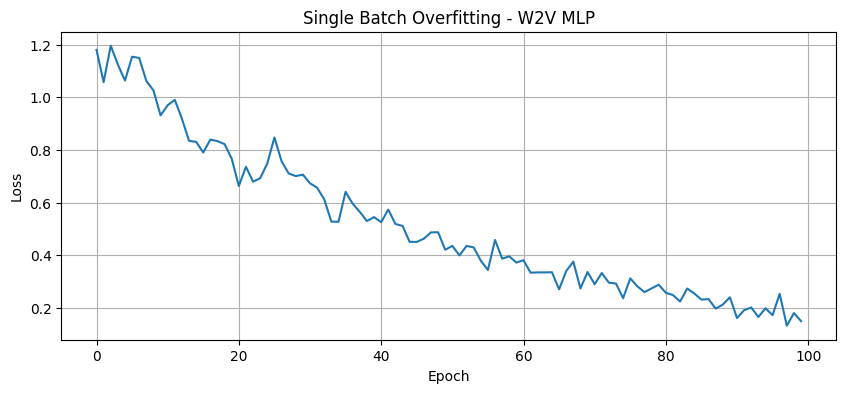


Final loss: 0.1491 (should be close to 0)


In [32]:
# Overfit single batch to verify model can learn
model_w2v_mlp = W2V_MLP(input_size=100, hidden_size=256, num_classes=num_classes).to(device)
optimizer = optim.Adam(model_w2v_mlp.parameters(), lr=0.001)

X_single, y_single = next(iter(train_loader))
X_single, y_single = X_single.to(device), y_single.to(device)

losses = []
for epoch in range(100):
    model_w2v_mlp.train()
    optimizer.zero_grad()
    outputs = model_w2v_mlp(X_single)
    loss = criterion(outputs, y_single)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Single Batch Overfitting - W2V MLP')
plt.grid(True)
plt.show()

print(f"\nFinal loss: {losses[-1]:.4f} (should be close to 0)")

### 5.3 Learning Rate Selection

LR: 0.0001, Final Loss: 0.9503
LR: 0.0005, Final Loss: 0.9070
LR: 0.001, Final Loss: 0.9046
LR: 0.005, Final Loss: 0.9139
LR: 0.01, Final Loss: 0.9220


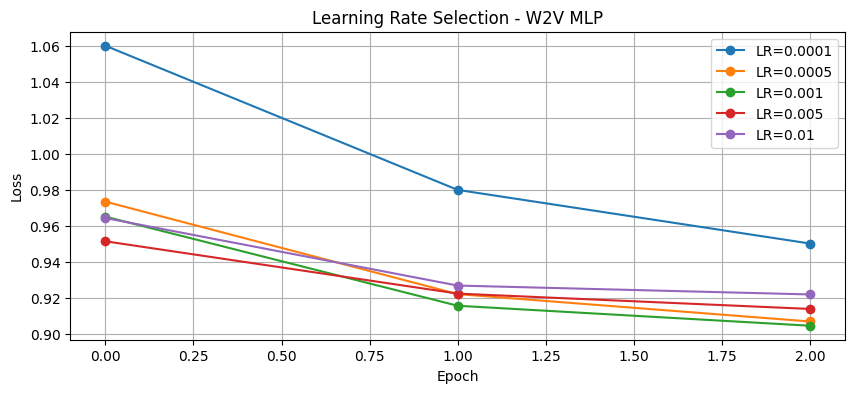

In [33]:
# Test different learning rates
learning_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01]
lr_results = {}

for lr in learning_rates:
    model = W2V_MLP(input_size=100, hidden_size=256, num_classes=num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    model.train()
    for epoch in range(3):
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_loader))
    
    lr_results[lr] = losses
    print(f"LR: {lr}, Final Loss: {losses[-1]:.4f}")

# Plot results
plt.figure(figsize=(10, 4))
for lr, losses in lr_results.items():
    plt.plot(losses, marker='o', label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Rate Selection - W2V MLP')
plt.legend()
plt.grid(True)
plt.show()

### 5.4 Train with Best LR and LR Scheduling

In [65]:
# Full training with best LR and scheduling
best_lr = 0.001  # Adjust based on above results
model_w2v_mlp = W2V_MLP(input_size=100, hidden_size=256, num_classes=num_classes, dropout=0.5).to(device)
# Add weight decay (L2 regularization) to prevent overfitting
optimizer = optim.Adam(model_w2v_mlp.parameters(), lr=best_lr, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
    
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    return total_loss / len(loader), correct / total

# Training loop with Early Stopping
num_epochs = 30
train_losses, train_accs = [], []
val_losses, val_accs = [], []

# Early stopping parameters
best_val_loss = float('inf')
patience = 5
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_w2v_mlp, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model_w2v_mlp, val_loader, criterion)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        best_model_state = model_w2v_mlp.state_dict().copy()
        print(f"  → New best validation loss: {best_val_loss:.4f}")
    else:
        patience_counter += 1
        print(f"  → No improvement for {patience_counter} epoch(s)")
        
    if patience_counter >= patience:
        print(f"\\nEarly stopping triggered after {epoch+1} epochs")
        # Restore best model
        model_w2v_mlp.load_state_dict(best_model_state)
        break

print(f"\n=== Model 2: Word2Vec + MLP ===")
print(f"Best Validation Accuracy: {max(val_accs):.4f}")

Epoch 1/30 - Train Loss: 0.9593, Train Acc: 0.5246, Val Loss: 0.8949, Val Acc: 0.5812
  → New best validation loss: 0.8949
Epoch 2/30 - Train Loss: 0.9170, Train Acc: 0.5603, Val Loss: 0.8860, Val Acc: 0.5801
  → New best validation loss: 0.8860
Epoch 3/30 - Train Loss: 0.9038, Train Acc: 0.5720, Val Loss: 0.8667, Val Acc: 0.5940
  → New best validation loss: 0.8667
Epoch 4/30 - Train Loss: 0.8962, Train Acc: 0.5757, Val Loss: 0.8627, Val Acc: 0.5950
  → New best validation loss: 0.8627
Epoch 5/30 - Train Loss: 0.8904, Train Acc: 0.5788, Val Loss: 0.8524, Val Acc: 0.6028
  → New best validation loss: 0.8524
Epoch 6/30 - Train Loss: 0.8846, Train Acc: 0.5817, Val Loss: 0.8523, Val Acc: 0.6036
  → New best validation loss: 0.8523
Epoch 7/30 - Train Loss: 0.8816, Train Acc: 0.5866, Val Loss: 0.8527, Val Acc: 0.5964
  → No improvement for 1 epoch(s)
Epoch 8/30 - Train Loss: 0.8794, Train Acc: 0.5888, Val Loss: 0.8594, Val Acc: 0.6019
  → No improvement for 2 epoch(s)
Epoch 9/30 - Train Los

### 5.5 Learning Curves

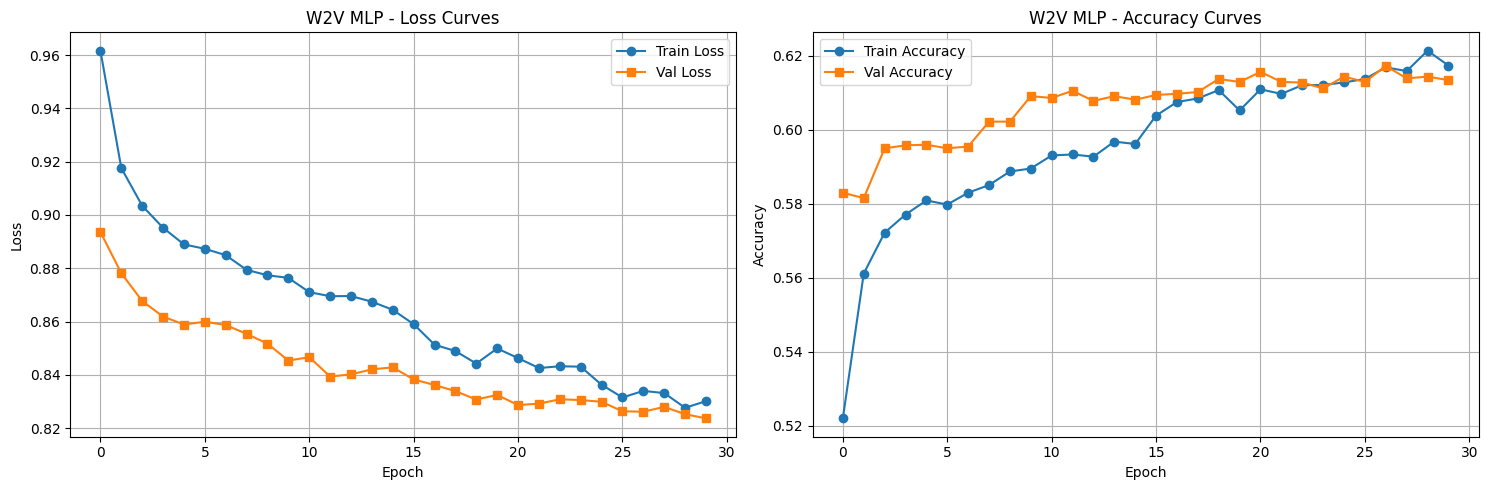

In [35]:
# Plot learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('W2V MLP - Loss Curves')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='Train Accuracy', marker='o')
ax2.plot(val_accs, label='Val Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('W2V MLP - Accuracy Curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**Word2Vec + MLP**:



   - Used the same Word2Vec embeddings as features.

   - Built a multi-layer perceptron (MLP) with batch normalization, dropout, and weight decay for regularization.

   - Tuned learning rate and applied early stopping to prevent overfitting.

   - Visualized learning curves and compared training/validation performance.



**Key observations and lessons learned:**

- Adding dropout and batch normalization significantly reduced overfitting and improved generalization.

- Careful tuning of the learning rate and use of early stopping helped achieve better validation accuracy and prevented unnecessary training.

- Monitoring learning curves was essential for diagnosing overfitting and guiding model improvements.

- The MLP architecture provided more flexibility and capacity compared to logistic regression, but required stronger regularization to avoid overfitting.


## 6. Model 3: Embedding from Scratch + MLP

In [53]:
# Build vocabulary
def build_vocab(texts, min_freq=2):
    """Build vocabulary from tokenized texts"""
    word_freq = Counter()
    for tokens in texts:
        word_freq.update(tokens)
    
    vocab = {'<PAD>': 0, '<UNK>': 1}
    idx = 2
    for word, freq in word_freq.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

vocab = build_vocab(train_df_aug['tokens'].tolist(), min_freq=2)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 13201


In [54]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_length=100):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        tokens = self.texts[idx]
        indices = [self.vocab.get(token, self.vocab['<UNK>']) for token in tokens]
        
        # Pad or truncate
        if len(indices) < self.max_length:
            indices += [self.vocab['<PAD>']] * (self.max_length - len(indices))
        else:
            indices = indices[:self.max_length]
        
        return torch.LongTensor(indices), torch.LongTensor([self.labels[idx]])

# Create datasets
max_length = 100
train_text_dataset = TextDataset(train_df_aug['tokens'].tolist(), train_df_aug['label'].tolist(), vocab, max_length)
val_text_dataset = TextDataset(val_df['tokens'].tolist(), val_df['label'].tolist(), vocab, max_length)

train_text_loader = DataLoader(train_text_dataset, batch_size=32, shuffle=True)
val_text_loader = DataLoader(val_text_dataset, batch_size=32, shuffle=False)

In [76]:
class EmbeddingMLP(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_classes, dropout=0.5):
        super(EmbeddingMLP, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.mlp = nn.Sequential(
            
            nn.Linear(embed_size, 64),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_size, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.BatchNorm1d(hidden_size // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_size // 4, num_classes)
        )
    
    def forward(self, x):
        # x: (batch_size, seq_length)
        embedded = self.embedding(x)  # (batch_size, seq_length, embed_size)
        pooled = embedded.mean(dim=1)  # (batch_size, embed_size)
        return self.mlp(pooled)

### 6.1 Check Initial Loss

In [81]:
model_emb = EmbeddingMLP(vocab_size, embed_size=128, hidden_size=64, num_classes=num_classes).to(device)

# Check initial loss
model_emb.eval()
with torch.no_grad():
    X_batch, y_batch = next(iter(train_text_loader))
    X_batch, y_batch = X_batch.to(device), y_batch.squeeze().to(device)
    outputs = model_emb(X_batch)
    initial_loss = criterion(outputs, y_batch)
    print(f"Initial loss: {initial_loss.item():.4f}")
    print(f"Expected random loss (log({num_classes})): {np.log(num_classes):.4f}")

Initial loss: 1.1316
Expected random loss (log(3)): 1.0986


### 6.2 Overfit a Single Batch

Epoch 20, Loss: 0.6626
Epoch 40, Loss: 0.3084
Epoch 60, Loss: 0.1246
Epoch 80, Loss: 0.1335
Epoch 100, Loss: 0.0693


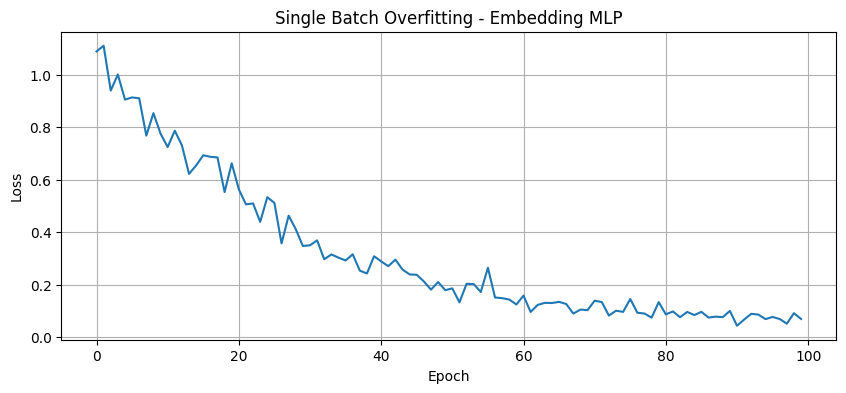


Final loss: 0.0693 (should be close to 0)


In [82]:
model_emb = EmbeddingMLP(vocab_size, embed_size=128, hidden_size=256, num_classes=num_classes).to(device)
optimizer = optim.Adam(model_emb.parameters(), lr=0.001)

X_single, y_single = next(iter(train_text_loader))
X_single, y_single = X_single.to(device), y_single.squeeze().to(device)

losses = []
for epoch in range(100):
    model_emb.train()
    optimizer.zero_grad()
    outputs = model_emb(X_single)
    loss = criterion(outputs, y_single)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Single Batch Overfitting - Embedding MLP')
plt.grid(True)
plt.show()

print(f"\nFinal loss: {losses[-1]:.4f} (should be close to 0)")

### 6.3 Learning Rate Selection

LR: 0.0001, Final Loss: 1.0684
LR: 0.0005, Final Loss: 0.8393
LR: 0.001, Final Loss: 0.7364
LR: 0.005, Final Loss: 0.6108
LR: 0.01, Final Loss: 0.6000


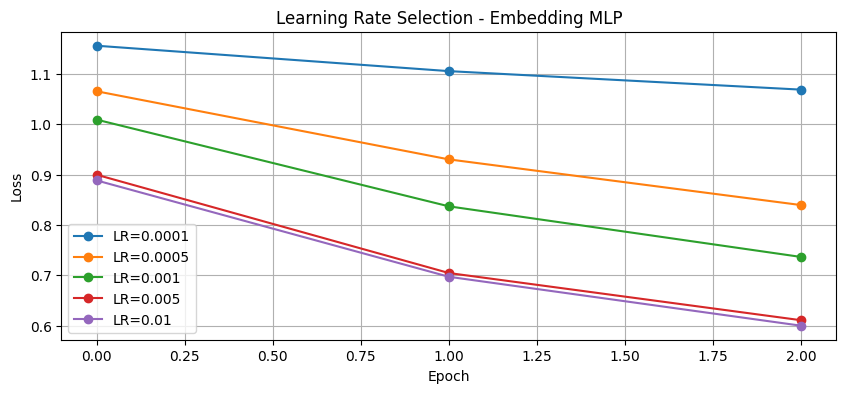

In [83]:
learning_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01]
lr_results_emb = {}

for lr in learning_rates:
    model = EmbeddingMLP(vocab_size, embed_size=128, hidden_size=256, num_classes=num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    model.train()
    for epoch in range(3):
        epoch_loss = 0
        for X_batch, y_batch in train_text_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.squeeze().to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_text_loader))

    
    lr_results_emb[lr] = losses
    print(f"LR: {lr}, Final Loss: {losses[-1]:.4f}")

plt.figure(figsize=(10, 4))
for lr, losses in lr_results_emb.items():
    plt.plot(losses, marker='o', label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Rate Selection - Embedding MLP')
plt.legend()
plt.grid(True)
plt.show()

### 6.4 Full Training with LR Scheduling

In [93]:
best_lr = 0.0001  # Adjust based on above results
model_emb = EmbeddingMLP(vocab_size, embed_size=128, hidden_size=256, num_classes=num_classes, dropout=0.6).to(device)
# Add weight decay (L2 regularization) to prevent overfitting
optimizer = optim.Adam(model_emb.parameters(), lr=best_lr, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

def train_epoch_emb(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.squeeze().to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
    
    return total_loss / len(loader), correct / total

def evaluate_emb(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.squeeze().to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    return total_loss / len(loader), correct / total

# Training loop with Early Stopping
num_epochs = 30
train_losses_emb, train_accs_emb = [], []
val_losses_emb, val_accs_emb = [], []

# Early stopping parameters
best_val_loss = float('inf')
patience = 5
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch_emb(model_emb, train_text_loader, optimizer, criterion)
    val_loss, val_acc = evaluate_emb(model_emb, val_text_loader, criterion)
    
    train_losses_emb.append(train_loss)
    train_accs_emb.append(train_acc)
    val_losses_emb.append(val_loss)
    val_accs_emb.append(val_acc)
    
    scheduler.step()
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        best_model_state = model_emb.state_dict().copy()
        print(f"  → New best validation loss: {best_val_loss:.4f}")
    else:
        patience_counter += 1
        print(f"  → No improvement for {patience_counter} epoch(s)")
        
    if patience_counter >= patience:
        print(f"\\nEarly stopping triggered after {epoch+1} epochs")
        # Restore best model
        model_emb.load_state_dict(best_model_state)
        break

print(f"\n=== Model 3: Embedding from Scratch + MLP ===")
print(f"Best Validation Accuracy: {max(val_accs_emb):.4f}")

Epoch 1/30 - Train Loss: 1.1536, Train Acc: 0.3591, Val Loss: 1.0769, Val Acc: 0.4196
  → New best validation loss: 1.0769
Epoch 2/30 - Train Loss: 1.1059, Train Acc: 0.3890, Val Loss: 1.0576, Val Acc: 0.4417
  → New best validation loss: 1.0576
Epoch 3/30 - Train Loss: 1.0739, Train Acc: 0.4175, Val Loss: 1.0332, Val Acc: 0.4653
  → New best validation loss: 1.0332
Epoch 4/30 - Train Loss: 1.0412, Train Acc: 0.4523, Val Loss: 1.0049, Val Acc: 0.4892
  → New best validation loss: 1.0049
Epoch 5/30 - Train Loss: 1.0174, Train Acc: 0.4735, Val Loss: 0.9846, Val Acc: 0.5052
  → New best validation loss: 0.9846
Epoch 6/30 - Train Loss: 1.0022, Train Acc: 0.4853, Val Loss: 0.9695, Val Acc: 0.5150
  → New best validation loss: 0.9695
Epoch 7/30 - Train Loss: 0.9878, Train Acc: 0.4993, Val Loss: 0.9619, Val Acc: 0.5206
  → New best validation loss: 0.9619
Epoch 8/30 - Train Loss: 0.9769, Train Acc: 0.5050, Val Loss: 0.9611, Val Acc: 0.5286
  → New best validation loss: 0.9611
Epoch 9/30 - Tra

### 6.5 Learning Curves

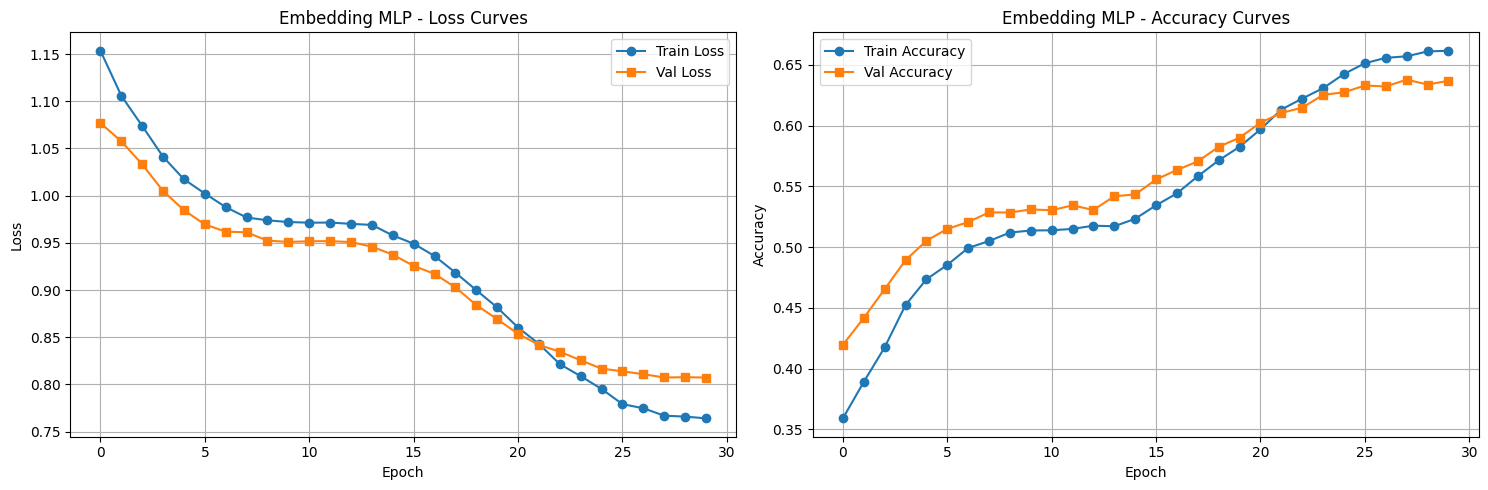

In [94]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses_emb, label='Train Loss', marker='o')
ax1.plot(val_losses_emb, label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Embedding MLP - Loss Curves')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs_emb, label='Train Accuracy', marker='o')
ax2.plot(val_accs_emb, label='Val Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Embedding MLP - Accuracy Curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**Embedding from Scratch + MLP**:



   - Built a vocabulary from the training data and encoded texts as padded sequences of word indices.

   - Trained an embedding layer from scratch within a deep MLP architecture.

   - Applied strong regularization (dropout, batch norm, weight decay, early stopping, learning rate scheduling).

   - Performed data augmentation to increase robustness.

   - Analyzed learning curves and addressed overfitting with advanced techniques.



**Key observations and lessons learned:**

- Increasing the dropout rate helped reduce overfitting and improved model generalization.

- Lower learning rates led to more stable training and better validation performance.

- Using a cosine learning rate scheduler contributed to smoother convergence and model stability.

- Deeper architectures (more layers) tended to perform better, but we limited the model to three layers to maintain stability and avoid excessive complexity.


## 7. Final Comparison

FINAL RESULTS SUMMARY

Model 1: Word2Vec + Logistic Regression
  Validation Accuracy: 0.5822

Model 2: Word2Vec + MLP
  Best Validation Accuracy: 0.6176

Model 3: Embedding from Scratch + MLP
  Best Validation Accuracy: 0.6377



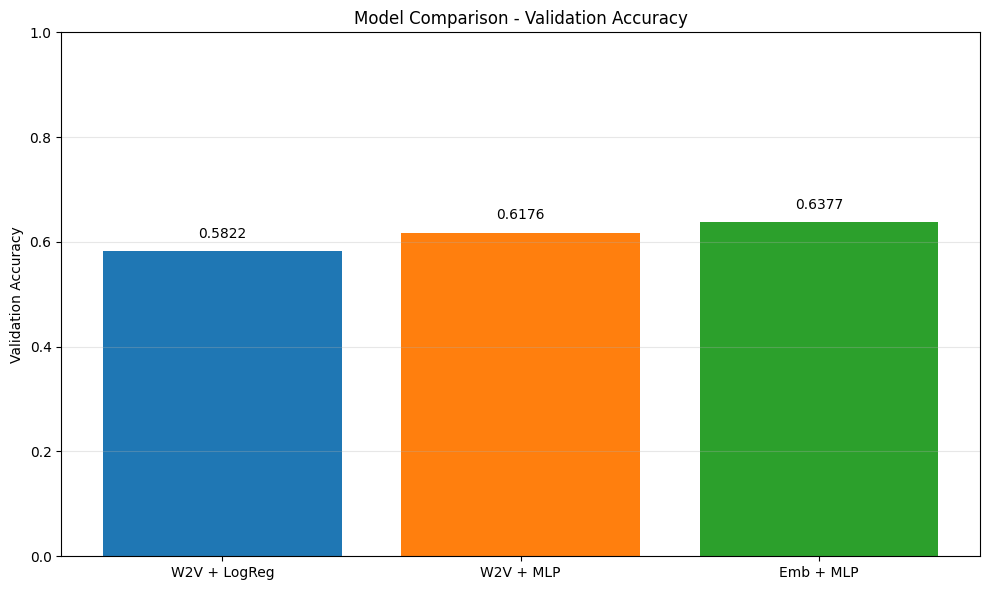

In [95]:
print("="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"\nModel 1: Word2Vec + Logistic Regression")
print(f"  Validation Accuracy: {accuracy:.4f}")
print(f"\nModel 2: Word2Vec + MLP")
print(f"  Best Validation Accuracy: {max(val_accs):.4f}")
print(f"\nModel 3: Embedding from Scratch + MLP")
print(f"  Best Validation Accuracy: {max(val_accs_emb):.4f}")
print("\n" + "="*60)

# Bar plot comparison
models = ['W2V + LogReg', 'W2V + MLP', 'Emb + MLP']
accuracies = [accuracy, max(val_accs), max(val_accs_emb)]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('Validation Accuracy')
plt.title('Model Comparison - Validation Accuracy')
plt.ylim([0, 1])
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary



This notebook implemented three text classification approaches on a multiclass sentiment analysis dataset, following best practices for robust model development and evaluation:



- Word2vec + multinomial
- Word2vec + MPL
- Embedding from scratch + MLP




This project demonstrates a full pipeline for text classification, from data loading and preprocessing to model selection, training, regularization, and evaluation.